In [1]:
import cv2 as cv
import numpy as np
import os
import math
from matplotlib import pyplot as plt
import scipy
from tqdm import tqdm

from numpy.lib.stride_tricks import sliding_window_view

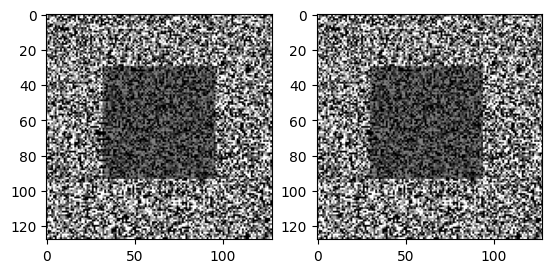

In [43]:
img_left = cv.imread("input/pair0-L.png", cv.IMREAD_GRAYSCALE) /255
img_right = cv.imread("input/pair0-R.png", cv.IMREAD_GRAYSCALE) /255
plt.subplot(121)
plt.imshow(img_left, cmap = 'gray')
plt.subplot(122)
plt.imshow(img_right, cmap = 'gray')
plt.show()

In [130]:
window_size = (10,10)
L = img_left
R = img_right
L_windows = sliding_window_view(L, window_size)
R_windows = sliding_window_view(R, window_size)
diff_matrix = np.zeros(L_windows.shape[:2])

print("calculating windows")
for i in tqdm(range(L_windows.shape[0])):
    for j in range(L_windows.shape[1]):
        window = R_windows[i,j]
        min_index = 0
        min_value = np.inf
        for k in range(R_windows.shape[1]):
            diff = np.sum(window - L_windows[i,k])
            diff = np.abs(diff)
            if diff < min_value:
                min_value = diff
                min_index = k
        diff_matrix[i][j] = min_index

for i in range(diff_matrix.shape[0]):
    for j in range(diff_matrix.shape[1]):
        diff_matrix[i,j] -= j

diff_matrix = np.astype(diff_matrix, int)



calculating windows


100%|██████████| 119/119 [00:36<00:00,  3.29it/s]


In [220]:
sliding_window_size = (15,15)
sliding_window_left = sliding_window_view(img_left, sliding_window_size)
sliding_window_right = sliding_window_view(img_right, sliding_window_size)
sliding_window_diff = sliding_window_left[:,:,None] - sliding_window_right[:,None]


In [235]:
print(sliding_window_left[:,:,None].shape)
print(sliding_window_right.shape) 
(sliding_window_right + sliding_window_left[:,:,None]).shape
# sliding_window_right[:,None].shape

(114, 114, 1, 15, 15)
(114, 114, 15, 15)


(114, 114, 114, 15, 15)

In [221]:
print(sliding_window_diff.shape)
diff_sum = np.square(sliding_window_diff).sum(axis=(-2,-1))
diff_sum.shape

(114, 114, 114, 15, 15)


(114, 114, 114)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


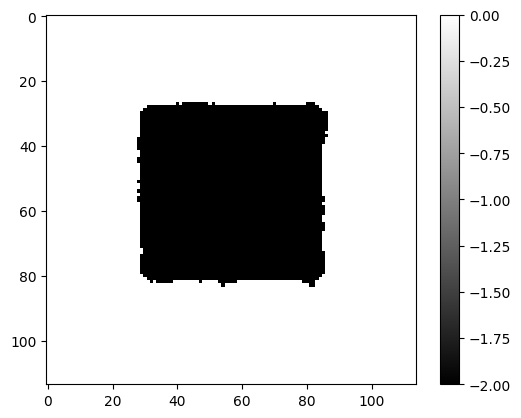

In [222]:
min_diff = np.argmin(diff_sum, axis=-1)
for i in range(min_diff.shape[0]):
    for j in range(min_diff.shape[1]):
        min_diff[i,j] -= j
min_diff = np.astype(min_diff, int)
plt.imshow(min_diff, cmap = 'gray')
plt.colorbar()
print(min_diff)


In [4]:
a = np.array([[1,2,3],[1,2,4],[1,2,3]])
# print(a[:,:,None].shape)
# print(a[:,None,:].shape)
# print(a.shape)
# (a[:,:,None] - a[:]).shape
a[:]
# np.array([[[1,2,3]],[[2,3,4]]]) - np.array([[1],[2],[3]])

array([[1, 2, 3],
       [1, 2, 4],
       [1, 2, 3]])

In [83]:
a = np.array([[1,4,4,8], [1,4,4,8], [1,4,4,8], [1,4,4,8]])
a = np.arange(16).reshape(4, 4).astype(float)
print(a)
# cv.blur(a, (3,3))
s=3
kernel = np.ones((s,s))
# cv.boxFilter(a, -1, (3,3))
display(cv.filter2D(a,-1, kernel))

display(cv.blur(a, (3,3)))

# kernel = np.ones((1,1),np.float32)/25
# dst = cv.filter2D(a,-1,kernel)

[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]


array([[ 30.,  33.,  42.,  45.],
       [ 42.,  45.,  54.,  57.],
       [ 78.,  81.,  90.,  93.],
       [ 90.,  93., 102., 105.]])

array([[ 3.33333333,  3.66666667,  4.66666667,  5.        ],
       [ 4.66666667,  5.        ,  6.        ,  6.33333333],
       [ 8.66666667,  9.        , 10.        , 10.33333333],
       [10.        , 10.33333333, 11.33333333, 11.66666667]])

In [84]:
# np.pad(img_left, ((0,5),(0,5)), mode='constant', constant_values=0)
x = np.minimum(img_left,img_right)

a[0,1] = 0
np.where(a[:,1:] == a[:,:-1])
a[1:] = a[0:-1]

TypeError: slice indices must be integers or None or have an __index__ method